In [40]:
import pandas as pd

# Leser inn alle Yelp-datafiler vi trenger
business = pd.read_json("yelp_business.json", lines=True)
review = pd.read_json("yelp_review.json", lines=True)
user = pd.read_json("yelp_user.json", lines=True)  
checkin = pd.read_json("yelp_checkin.json", lines=True)  
tip = pd.read_json("yelp_tip.json", lines=True)  

# Bekrefter at alt er lastet inn
print("Business:", business.shape)
print("Review:", review.shape)
print("User:", user.shape)


Business: (188593, 22)
Review: (188593, 7)
User: (188593, 6)


In [41]:
# Utforsk 'business' dataene
print("Business")
print("Kolonner:", business.columns)
print("\nInfo:")
print(business.info())
print("\nFørste rader:")
print(business.head())

# Utforske 'review' dataene
print("Review")
print("Kolonner:", review.columns)
print("\nInfo:")
print(review.info())
print("\nFørste rader:")
print(review.head())

Business
Kolonner: Index(['address', 'alcohol?', 'attributes', 'business_id', 'categories',
       'city', 'good_for_kids', 'has_bike_parking', 'has_wifi', 'hours',
       'is_open', 'latitude', 'longitude', 'name', 'neighborhood',
       'postal_code', 'price_range', 'review_count', 'stars', 'state',
       'take_reservations', 'takes_credit_cards'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188593 entries, 0 to 188592
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   address             188593 non-null  object 
 1   alcohol?            188593 non-null  int64  
 2   attributes          162807 non-null  object 
 3   business_id         188593 non-null  object 
 4   categories          188052 non-null  object 
 5   city                188593 non-null  object 
 6   good_for_kids       188593 non-null  int64  
 7   has_bike_parking    188593 non-null  int64  
 8   h

In [42]:
combined = pd.merge(business, review, on="business_id", how="inner")
print("Antall rader etter merge:", len(combined))
print("Kolonner i combined:", combined.columns)
combined.head()

Antall rader etter merge: 188593
Kolonner i combined: Index(['address', 'alcohol?', 'attributes', 'business_id', 'categories',
       'city', 'good_for_kids', 'has_bike_parking', 'has_wifi', 'hours',
       'is_open', 'latitude', 'longitude', 'name', 'neighborhood',
       'postal_code', 'price_range', 'review_count', 'stars', 'state',
       'take_reservations', 'takes_credit_cards', 'average_review_age',
       'average_review_length', 'average_review_sentiment',
       'number_funny_votes', 'number_cool_votes', 'number_useful_votes'],
      dtype='object')


,address,alcohol?,attributes,business_id,categories,city,good_for_kids,has_bike_parking,has_wifi,hours,...,stars,state,take_reservations,takes_credit_cards,average_review_age,average_review_length,average_review_sentiment,number_funny_votes,number_cool_votes,number_useful_votes
0,1314 44 Avenue NE,0,"{'BikeParking': 'False', 'BusinessAcceptsCredi...",Apn5Q_b6Nz61Tq4XzPdf9A,"Tours, Breweries, Pizza, Restaurants, Food, Ho...",Calgary,1,0,0,"{'Monday': '8:30-17:0', 'Tuesday': '11:0-21:0'...",...,4.0,AB,1,1,618.250000,532.916667,0.865342,6,5,13
1,,0,"{'Alcohol': 'none', 'BikeParking': 'False', 'B...",AjEbIBw6ZFfln7ePHha9PA,"Chicken Wings, Burgers, Caterers, Street Vendo...",Henderson,1,0,0,"{'Friday': '17:0-23:0', 'Saturday': '17:0-23:0...",...,4.5,NV,0,1,371.666667,481.333333,0.975000,0,1,1
2,1335 rue Beaubien E,1,"{'Alcohol': 'beer_and_wine', 'Ambience': '{'ro...",O8S5hYJ1SMc8fA4QBtVujA,"Breakfast & Brunch, Restaurants, French, Sandw...",Montréal,1,1,1,"{'Monday': '10:0-22:0', 'Tuesday': '10:0-22:0'...",...,4.0,QC,1,0,1106.200000,252.000000,0.301240,0,2,1
3,211 W Monroe St,0,None,bFzdJJ3wp3PZssNEsyU23g,"Insurance, Financial Services",Phoenix,0,0,0,None,...,1.5,AZ,0,0,398.500000,672.625000,-0.060500,1,0,3
4,2005 Alyth Place SE,0,{'BusinessAcceptsCreditCards': 'True'},8USyCYqpScwiNEb58Bt6CA,"Home & Garden, Nurseries & Gardening, Shopping...",Calgary,0,0,0,"{'Monday': '8:0-17:0', 'Tuesday': '8:0-17:0', ...",...,2.0,AB,0,1,1412.750000,1015.500000,0.372550,0,0,4


In [43]:
print("Er business_id unik i business?", business["business_id"].is_unique)
print("Er business_id unik i review?", review["business_id"].is_unique)

print("Shape på combined:", combined.shape)
print("Antall ulike business_id i combined:", combined["business_id"].nunique())

Er business_id unik i business? True
Er business_id unik i review? True
Shape på combined: (188593, 28)
Antall ulike business_id i combined: 188593


In [44]:
nan_counts = combined.isna().sum().sort_values(ascending=False)

print("Antall manglede verdier per kolonne:")
print(nan_counts[nan_counts > 0])

Antall manglede verdier per kolonne:
hours         44802
attributes    25786
categories      541
latitude          6
longitude         6
dtype: int64


In [45]:
# Dropper 'hours' og 'attributes'
combined_clean = combined.drop(columns=["hours", "attributes"])
# Dropper rader som mangler latitude eller longitude
combined_clean = combined_clean.dropna(subset=['latitude', 'longitude'])

print("Form etter rens:", combined_clean.shape)

Form etter rens: (188586, 26)


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
# Velger target variabelen
y = combined_clean['stars']
# Kun numeriske features (dropper target)
numeric_features = combined_clean.select_dtypes(include=["int64", "float64"]).drop(columns=['stars'])
X = numeric_features.copy()

In [47]:
print("X_shape, y_shape:", X.shape, y.shape)
print("Totale nan i X:", int(X.isna().sum().sum()))

X_shape, y_shape: (188586, 17) (188586,)
Totale nan i X: 0


In [48]:
# Korrelasjon mot target variabel for å finne features som relaterer til 'stars'
corr_with_target = X.corrwith(y)
corr_sorted = corr_with_target.sort_values(ascending=False) # Sorter fra sterkest positiv til svakest
corr_sorted.head(15), corr_sorted.tail(15) # Gir både topp 15 og bunn 15

(average_review_sentiment    0.782187
 has_bike_parking            0.068106
 is_open                     0.051906
 number_cool_votes           0.043379
 takes_credit_cards          0.037754
 review_count                0.032415
 number_funny_votes          0.001322
 number_useful_votes        -0.000064
 take_reservations          -0.024482
 good_for_kids              -0.030374
 has_wifi                   -0.039852
 alcohol?                   -0.043327
 price_range                -0.052549
 longitude                  -0.082402
 latitude                   -0.093235
 dtype: float64,
 is_open                  0.051906
 number_cool_votes        0.043379
 takes_credit_cards       0.037754
 review_count             0.032415
 number_funny_votes       0.001322
 number_useful_votes     -0.000064
 take_reservations       -0.024482
 good_for_kids           -0.030374
 has_wifi                -0.039852
 alcohol?                -0.043327
 price_range             -0.052549
 longitude               -0.

In [49]:
# Set a threhold for 'not quite irrelevant'
threshold = 0.05
# using absolute value so both positive and negative correlations stays
keep = corr_with_target[corr_with_target.abs() >= threshold].index.tolist()
X_sel = X[keep].copy() # Makes a clean feature matrix for modeling
print("Valgte features:", keep)
print("X_sel shape:", X_sel.shape)

Valgte features: ['has_bike_parking', 'is_open', 'latitude', 'longitude', 'price_range', 'average_review_age', 'average_review_length', 'average_review_sentiment']
X_sel shape: (188586, 8)


In [50]:
import numpy as np
# Korrelasjonsmatrise mellom beholdte features
cm = X_sel.corr().abs()

upper = cm.where(np.tril(np.ones(cm.shape, dtype=bool)))

high_pairs = [
    (c1, c2, cm.loc[c1, c2])
     for c1 in upper.columns
    for c2 in upper.columns
    if c1 != c2 and upper.loc[c1, c2] > 0.90]
high_pairs[:10]

[]

In [51]:
from sklearn.model_selection import train_test_split
# Del data i trening og test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape: ", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)                                                

Train shape:  (150868, 17) (150868,)
Test shape:  (37718, 17) (37718,)


In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
# Opprett modellen
lr = LinearRegression()
# Train the model
lr.fit(X_train, y_train)
# Lag predikasjoner
y_pred = lr.predict(X_test)
# Evaluate the result
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("R2 score:", r2)
print("RMSE:", rmse)

R2 score: 0.6785616192612893
RMSE: 0.5738057458198077


In [53]:
# Sjekker hvilken faktor som påvirker mest
coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr.coef_})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print(coefficients)

                     Feature  Coefficient
13  average_review_sentiment     2.280221
4                    is_open     0.065791
9          take_reservations     0.030708
10        takes_credit_cards     0.025168
2           has_bike_parking     0.010148
6                  longitude     0.000823
15         number_cool_votes     0.000630
14        number_funny_votes    -0.000007
11        average_review_age    -0.000095
8               review_count    -0.000124
16       number_useful_votes    -0.000171
12     average_review_length    -0.000601
5                   latitude    -0.008029
7                price_range    -0.069512
1              good_for_kids    -0.131085
3                   has_wifi    -0.131963
0                   alcohol?    -0.145472


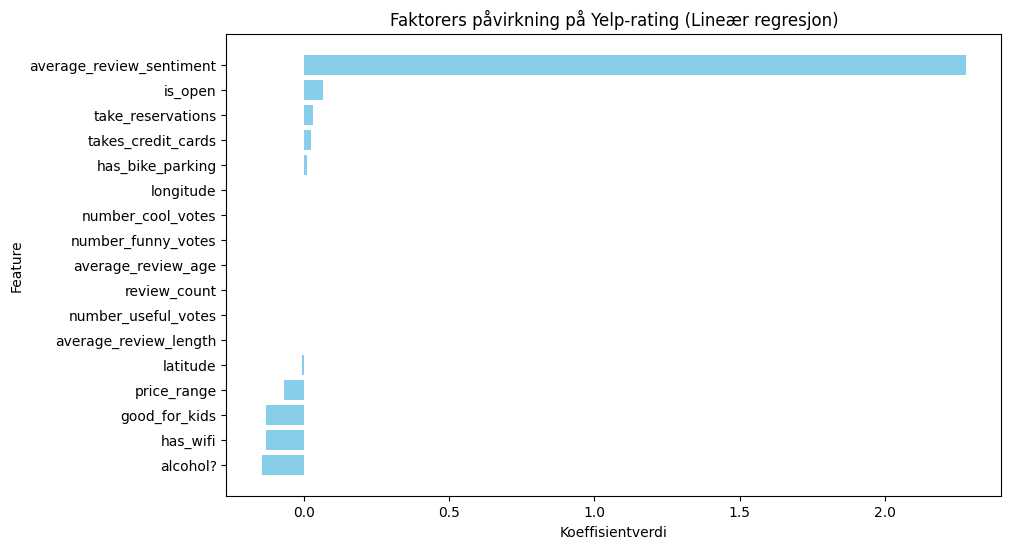

In [54]:
# Visualiser koeffisientene
import matplotlib.pyplot as plt
# DataFrame med features og tilhørende koeffisienter
coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr.coef_})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
# Plot koeffisienten
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='skyblue')
plt.xlabel("Koeffisientverdi")
plt.ylabel("Feature")
plt.title("Faktorers påvirkning på Yelp-rating (Lineær regresjon)")
plt.gca().invert_yaxis()  # Slik at høyeste vises øverst
plt.show()

In [55]:
# Feature selection basert på korrelasjon
corr_with_target = X.corrwith(y).abs()
threshold = 0.05
keep_cols = corr_with_target[corr_with_target >= threshold].index.tolist()
X_train_f = X_train[keep_cols]
X_test_f  = X_test[keep_cols]

# Standardisering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_f)
X_test_scaled  = scaler.transform(X_test_f)

# Tren lineær regresjons modell
from sklearn.linear_model import LinearRegression
lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

# Evaluer modell
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred_scaled = lr_scaled.predict(X_test_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))

print("R² (før/etter):", r2, "→", r2_scaled)
print("RMSE (før/etter):", rmse, "→", rmse_scaled)


R² (før/etter): 0.6785616192612893 → 0.6691885540788572
RMSE (før/etter): 0.5738057458198077 → 0.582111649521971


In [56]:
# Importer polyfeatures 
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train a new LR with poly features
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)
# Evaluer resultatene
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
print("R2:", r2_poly)
print("RMSE:", rmse_poly)

R2: 0.7126575766371483
RMSE: 0.542520186046132
